In [ ]:
import os

os.environ['CUDA_VISIBLE_DEVICES'] = '-1' # don't use GPU
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' #omit info

from learnMSA.align import AlignmentModel
from learnMSA.util import SequenceDataset
from learnMSA.util.visualize import plot_phmm

2026-07-16 12:09:12.823361: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1784196552.840372  606438 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784196552.845601  606438 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1784196552.859413  606438 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784196552.859426  606438 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784196552.859428  606438 computation_placer.cc:177] computation placer alr

In [2]:
from learnMSA.hmm.tf.util import load_dirichlet

In [13]:
c = 9
s = 23
prior = load_dirichlet(
    f"pfam_aa_{c}.weights",
    dim = s,
    components = c,
)

In [14]:
prior.mean()

<tf.Tensor: shape=(1, 1, 23), dtype=float32, numpy=
array([[[0.07748985, 0.04939144, 0.03929561, 0.04810629, 0.02903542,
         0.04975956, 0.05478439, 0.04763278, 0.03317586, 0.04267837,
         0.04905079, 0.05220047, 0.03405346, 0.0366241 , 0.03194755,
         0.07267135, 0.05671046, 0.02796234, 0.03350405, 0.0567626 ,
         0.0257456 , 0.02570827, 0.02570927]]], dtype=float32)>

In [15]:
prior.matrix()[0,0].numpy()[:c*s].reshape(c,s)

array([[2.6412275 , 2.5552902 , 1.8986726 , 2.1865108 , 0.71203744,
        2.1798916 , 3.355991  , 1.6514169 , 1.2966952 , 1.1673092 ,
        1.9797884 , 2.3595395 , 0.72902673, 1.0634327 , 1.2099842 ,
        2.9250662 , 2.462164  , 0.65438724, 1.1331624 , 1.6574507 ,
        0.01203312, 0.01192464, 0.01199718],
       [2.1571076 , 1.3701303 , 1.0943811 , 1.0657568 , 0.70701575,
        1.2988088 , 1.3032253 , 0.98669946, 1.176874  , 2.1396577 ,
        4.063155  , 1.1659749 , 1.0129815 , 1.5856068 , 1.0019454 ,
        1.5602319 , 1.6531706 , 0.93299776, 1.5212262 , 2.2527442 ,
        0.01198216, 0.01200784, 0.01194792],
       [1.5322222 , 1.623715  , 0.97838175, 0.87130344, 0.5284858 ,
        1.0827324 , 1.347613  , 0.6757454 , 0.7593904 , 0.8848826 ,
        1.2803438 , 1.5230074 , 0.62394184, 0.8092928 , 0.01836389,
        1.5223442 , 1.1533082 , 0.02183213, 0.8256298 , 1.0743003 ,
        0.0119211 , 0.01192635, 0.01192571],
       [2.0081472 , 1.5347286 , 1.2381842 , 1.735

In [16]:
prior.matrix()[0,0].numpy()[c*s:]

array([0.0014817 , 0.00090976, 0.004496  , 0.00557122, 0.07900057,
       0.00679706, 0.00122421, 0.102846  , 0.7976734 ], dtype=float32)

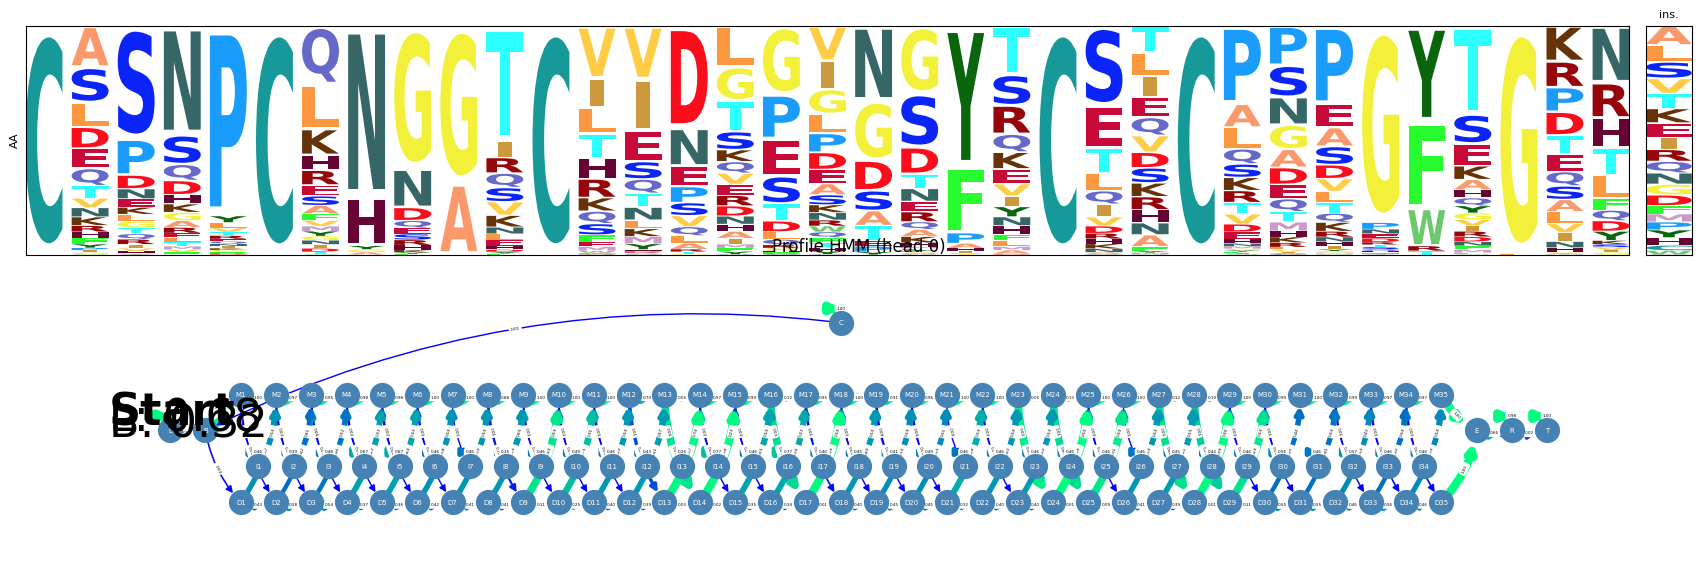

In [18]:
# Model built with:
# learnMSA --from_msa egf.ref
# --skip_training --no_noise --save_model egf.model
model_path = "../tmp/egf.model"
data_path = "../../snakeMSA/data/homfam/unaligned/egf.vie"

data = SequenceDataset(data_path)
alignment_model = AlignmentModel.load(model_path, data)

fig=plot_phmm(alignment_model.model.phmm_layer, head = 0, fast_mode = True)

In [10]:
alignment_model.model.phmm_layer.struct_emitter.prior.matrix()[0, 0].numpy()

array([0.03527978, 0.0467373 , 0.18725938, 0.00780227, 0.02864996,
       0.0293134 , 0.02710472, 0.01592394, 0.01352761, 0.07831699,
       0.00657615, 0.03550724, 0.11052648, 0.06365003, 0.03716148,
       0.07500053, 0.01954208, 0.20992854, 0.02097525, 0.00836317],
      dtype=float32)

In [ ]:
fig.savefig("egf_phmm.pdf", bbox_inches="tight") # type: ignore